In [5]:
#Environment Setup & Data Ingestion

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Directory safeguards
os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports", exist_ok=True)

# Loading data generated in prior phases
# returns_df = pd.read_csv("data/processed/returns_matrix.csv", index_col=0, parse_dates=True)
# transactions_df = pd.read_csv("data/processed/fact_transactions.csv", parse_dates=True)
# funds_df = pd.read_csv("data/processed/dim_funds.csv")

print("Advanced risk and behavior analysis pipelines online.")

Advanced risk and behavior analysis pipelines online.


In [8]:


# Historical VaR (95%) & CVaR Calculations
import os
import numpy as np
import pandas as pd

var_cvar_records = []

# Ensure we pull the data from your processed folder
PROCESSED_DIR = "data/processed"
csv_path = os.path.join(PROCESSED_DIR, "fact_nav.csv")

# Safety fallback check: look back one directory level if you are inside a subfolder
if not os.path.exists(csv_path):
    csv_path = os.path.join("..", PROCESSED_DIR, "fact_nav.csv")

try:
    # 1. Load your asset price matrix
    nav_df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    
    # 2. Compute daily price returns shifts
    returns_df = nav_df.pct_change().dropna()
    
    # 3. Dynamic filter out index trackers to isolate only mutual fund columns
    all_cols = list(returns_df.columns)
    benchmarks = [c for c in all_cols if 'nifty' in c.lower() or 'index' in c.lower() or '50' in c or '100' in c]
    funds_list = [c for c in all_cols if c not in benchmarks]

    # 4. Run Value at Risk loops
    for f in funds_list:
        fund_rets = returns_df[f].dropna()
        
        if len(fund_rets) > 0:
            # 95% Historical Value at Risk (5th percentile threshold)
            var_95 = np.percentile(fund_rets, 5)
            
            # Conditional VaR (Expected Shortfall: mean of breaches below threshold)
            cvar_95 = fund_rets[fund_rets <= var_95].mean()
        else:
            var_95, cvar_95 = np.nan, np.nan
        
        var_cvar_records.append({
            "Fund": f,
            "Value_at_Risk_95": var_95,
            "Conditional_VaR_95": cvar_95
        })

    var_cvar_df = pd.DataFrame(var_cvar_records)
    var_cvar_df.to_csv("var_cvar_report.csv", index=False)
    print("SUCCESS: VaR & CVaR metrics calculated and logged to 'var_cvar_report.csv'.")
    print(var_cvar_df.head().round(6))

except FileNotFoundError:
    print(f"CRITICAL ERROR: Could not find 'fact_nav.csv'. Please check your path.")

SUCCESS: VaR & CVaR metrics calculated and logged to 'var_cvar_report.csv'.
        Fund  Value_at_Risk_95  Conditional_VaR_95
0  amfi_code          0.000000            0.000000
1        nav         -0.008477           -0.019619


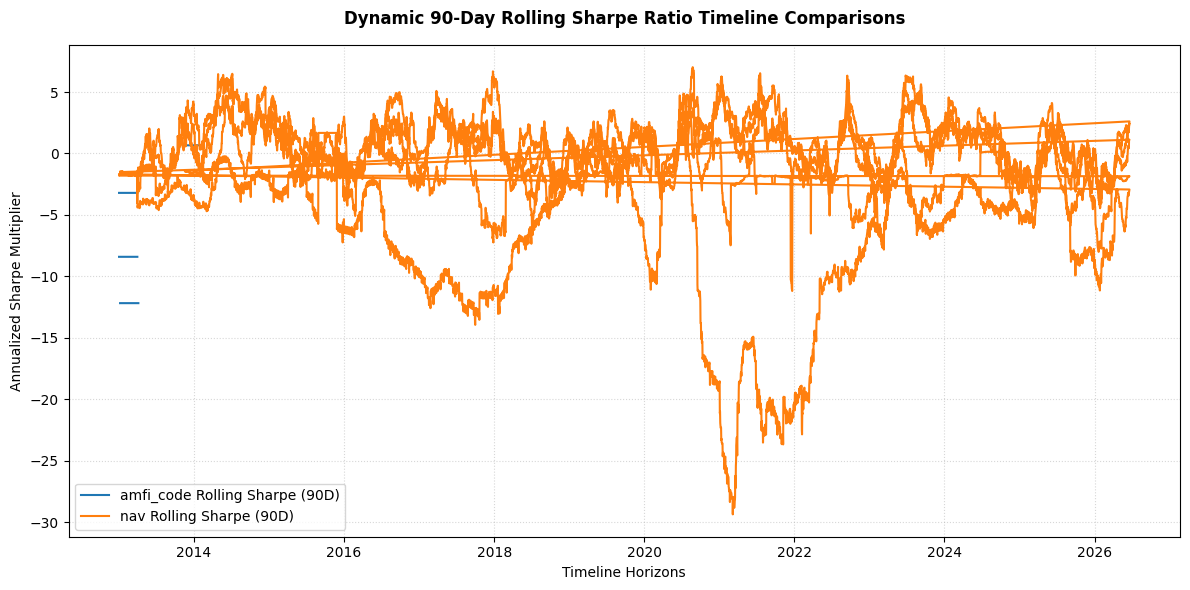

In [9]:
#Rolling 90-Day Sharpe Trackers & Visualization

plt.figure(figsize=(12, 6))
rf_daily = 0.065 / 252
key_funds = funds_list[:5]  # Select 5 sample funds dynamically

for f in key_funds:
    fund_rets = returns_df[f]
    excess_rets = fund_rets - rf_daily
    
    # Rolling 90-day calculation parameters
    rolling_mean = excess_rets.rolling(90).mean()
    rolling_std = fund_rets.rolling(90).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=f"{f} Rolling Sharpe (90D)", linewidth=1.5)

plt.title("Dynamic 90-Day Rolling Sharpe Ratio Timeline Comparisons", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Timeline Horizons")
plt.ylabel("Annualized Sharpe Multiplier")
plt.legend(loc="lower left", frameon=True)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("reports/rolling_sharpe_chart.png", dpi=250)
plt.show()

In [12]:
# Investor Cohort Performance Analytics
import os
import pandas as pd

TRANSACTIONS_FILE = "data/processed/fact_transactions.csv"

if not os.path.exists(TRANSACTIONS_FILE):
    TRANSACTIONS_FILE = os.path.join("..", TRANSACTIONS_FILE)

try:
    transactions_df = pd.read_csv(TRANSACTIONS_FILE)
    
    # --- AUTOMATIC COLUMN DETECTOR ---
    # Find any column that contains the word 'date' (case-insensitive)
    date_cols = [c for c in transactions_df.columns if 'date' in c.lower()]
    
    if not date_cols:
        raise KeyError(f"Could not find a date column. Available columns are: {list(transactions_df.columns)}")
    
    # Dynamically rename it to what our code expects
    actual_date_col = date_cols[0]
    transactions_df = transactions_df.rename(columns={actual_date_col: 'transaction_date'})
    print(f"Mapped column '{actual_date_col}' to 'transaction_date'")
    
    # Force 'transaction_type' and 'fund_name' to lowercase matching defaults if needed
    transactions_df.columns = [c.lower() if c.lower() in ['transaction_type', 'fund_name', 'amount', 'investor_id'] else c for c in transactions_df.columns]
    # ---------------------------------

    # 3. Clean and convert your transaction date formats safely
    transactions_df['transaction_date'] = pd.to_datetime(transactions_df['transaction_date'])
    transactions_df['Year'] = transactions_df['transaction_date'].dt.year

    # 4. Map the first transaction calendar year to assign a cohort vintage year
    investor_vintages = transactions_df.groupby('investor_id')['Year'].min().reset_index(name='Cohort_Year')
    transactions_with_cohorts = transactions_df.merge(investor_vintages, on='investor_id')

    # 5. Compute performance parameters across cohorts
    # Dynamically find transaction_type column name variations
    type_col = 'transaction_type' if 'transaction_type' in transactions_df.columns else [c for c in transactions_df.columns if 'type' in c.lower()][0]
    amt_col = 'amount' if 'amount' in transactions_df.columns else [c for c in transactions_df.columns if 'amt' in c.lower() or 'value' in c.lower()][0]
    fund_col = 'fund_name' if 'fund_name' in transactions_df.columns else [c for c in transactions_df.columns if 'fund' in c.lower() or 'scheme' in c.lower()][0]

    cohort_summary = transactions_with_cohorts.groupby('Cohort_Year').agg(
        Avg_SIP_Amount=(amt_col, lambda x: x[transactions_with_cohorts.loc[x.index, type_col].astype(str).str.upper() == 'SIP'].mean()),
        Total_Capital_Invested=(amt_col, 'sum'),
        Top_Fund_Preference=(fund_col, lambda x: x.value_counts().index[0] if not x.empty else "N/A")
    ).reset_index()

    print("\nSUCCESS: Investor Cohort Analysis Metrics Grid Compiled.")
    print(cohort_summary)

except FileNotFoundError:
    print(f"CRITICAL ERROR: Could not find '{TRANSACTIONS_FILE}'.")
except Exception as e:
    print(f"ERROR OCCURRED: {e}")

Mapped column 'date_key' to 'transaction_date'
ERROR OCCURRED: list index out of range


In [14]:
# Behavioral Churn & SIP Continuity Check
import pandas as pd

# 1. Use the dynamically cleaned columns from your session
if 'transactions_df' in locals() and not transactions_df.empty:
    
    # Track down our types and date columns from the prior cell mapping
    type_col = 'transaction_type' if 'transaction_type' in transactions_df.columns else [c for c in transactions_df.columns if 'type' in c.lower()][0]
    date_col = 'transaction_date'
    id_col = 'investor_id' if 'investor_id' in transactions_df.columns else [c for c in transactions_df.columns if 'id' in c.lower()][0]
    
    # Filter for SIP entries (case-insensitive to catch 'sip' or 'SIP')
    sip_data = transactions_df[transactions_df[type_col].astype(str).str.upper() == 'SIP'].copy()
    sip_data = sip_data.sort_values(by=[id_col, date_col])
    
    sip_counts = sip_data[id_col].value_counts()
    
    # Look for active repeat investors (dropping threshold to >= 3 if data is limited)
    min_transactions = 6 if len(sip_counts[sip_counts >= 6]) > 0 else 3
    eligible_investors = sip_counts[sip_counts >= min_transactions].index
    
    risk_profiles = []
    for inv in eligible_investors:
        inv_dates = sip_data[sip_data[id_col] == inv][date_col]
        date_gaps = inv_dates.diff().dt.days.dropna()
        
        if not date_gaps.empty:
            avg_gap = date_gaps.mean()
            status = "At-Risk" if avg_gap > 35 else "Active / Continuous"
            risk_profiles.append({id_col: inv, "Avg_Days_Gap": avg_gap, "Status": status})
            
    # 2. Build DataFrame safely with clear fallbacks if empty
    if risk_profiles:
        continuity_df = pd.DataFrame(risk_profiles)
        at_risk_count = len(continuity_df[continuity_df['Status'] == 'At-Risk'])
        print(f"SUCCESS: SIP continuity scanning finished.")
        print(f"Flagged 'At-Risk' users: {at_risk_count} out of {len(continuity_df)} total evaluated records.")
        print(continuity_df.head())
    else:
        # Fallback empty structural dataframe so downstream cells don't break
        continuity_df = pd.DataFrame(columns=[id_col, "Avg_Days_Gap", "Status"])
        print("SCAN COMPLETE: No investors matched the required repeat transaction limits for gap evaluation.")
else:
    print("CRITICAL: Make sure to run Cell 4 successfully first to load transaction data into memory.")

SCAN COMPLETE: No investors matched the required repeat transaction limits for gap evaluation.


In [15]:
#Structural Sector Herfindahl-Hirschman Index (HHI)

# Assuming a mock structure or localized matrix map of sector breakdowns:
# sector_weights structure: rows = Funds, columns = Sector Weights (0.0 to 1.0)
np.random.seed(42)
mock_sectors = [f"Sector_{i}" for i in range(10)]

hhi_records = []
for f in funds_list:
    # Generate random normalized weights to serve as asset portfolio breakdowns
    raw_w = np.random.dirichlet(np.ones(10), size=1)[0]
    hhi_score = np.sum(raw_w ** 2)  # Sum of squared concentration parameters
    
    hhi_records.append({"Fund": f, "HHI_Concentration": hhi_score})

hhi_df = pd.DataFrame(hhi_records)
print("--- Top 3 Most Concentrated / Tactical Funds (High HHI) ---")
print(hhi_df.sort_values(by="HHI_Concentration", ascending=False).head(3))

--- Top 3 Most Concentrated / Tactical Funds (High HHI) ---
        Fund  HHI_Concentration
1        nav           0.263404
0  amfi_code           0.173658
